<a href="https://colab.research.google.com/github/Jayakrishna143/portfolio-project/blob/main/cars_inside.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd,numpy as np ,requests
from bs4 import BeautifulSoup
from tqdm import tqdm

### Urls of Websites Each for Each city


In [6]:
# List of URLs
urls = [
    "https://www.cars24.com/buy-used-car/?sort=bestmatch&serveWarrantyCount=true&listingSource=Homepage_Filters&storeCityId=1",
    "https://www.cars24.com/buy-used-cars-ahmedabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1692",
    "https://www.cars24.com/buy-used-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686",
    "https://www.cars24.com/buy-used-cars-mumbai/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2378",
    "https://www.cars24.com/buy-used-cars-bangalore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=4709",
    "https://www.cars24.com/buy-used-cars-chennai/?sort=bestmatch&serveWarrantyCount=true&storeCityId=5732",
    "https://www.cars24.com/buy-used-cars-pune/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2423",
    "https://www.cars24.com/buy-used-cars-new-delhi/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2",
    "https://www.cars24.com/buy-used-cars-noida/?sort=bestmatch&serveWarrantyCount=true&storeCityId=134",
    "https://www.cars24.com/buy-used-cars-ghaziabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=132",
    "https://www.cars24.com/buy-used-cars-lucknow/?sort=bestmatch&serveWarrantyCount=true&storeCityId=290",
    "https://www.cars24.com/buy-used-cars-jaipur/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2130",
    "https://www.cars24.com/buy-used-cars-kolkata/?sort=bestmatch&serveWarrantyCount=true&storeCityId=777",
    "https://www.cars24.com/buy-used-cars-kochi/?sort=bestmatch&serveWarrantyCount=true&storeCityId=6356",
    "https://www.cars24.com/buy-used-cars-nashik/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2598",
    "https://www.cars24.com/buy-used-cars-coimbatore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=6105",
    "https://www.cars24.com/buy-used-cars-indore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2920",
    "https://www.cars24.com/buy-used-cars-patna/?sort=bestmatch&serveWarrantyCount=true&storeCityId=8184",
    "https://www.cars24.com/buy-used-cars-surat/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1605",
    "https://www.cars24.com/buy-used-cars-chandigarh/?sort=bestmatch&serveWarrantyCount=true&storeCityId=769",
    "https://www.cars24.com/buy-used-cars-ludhiana/?sort=bestmatch&serveWarrantyCount=true&storeCityId=666",
    "https://www.cars24.com/buy-used-cars-rajkot/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1606",
    "https://www.cars24.com/buy-used-cars-vadodara/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1674",
    "https://www.cars24.com/buy-used-cars-agra/?sort=bestmatch&serveWarrantyCount=true&storeCityId=136",
    "https://www.cars24.com/buy-used-cars-bhopal/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2987",
    "https://www.cars24.com/buy-used-cars-kota/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2234",
    "https://www.cars24.com/buy-used-cars-amritsar/?sort=bestmatch&serveWarrantyCount=true&storeCityId=684",
    'https://www.cars24.com/buy-used-cars-chandigarh-tricity/?sort=bestmatch&serveWarrantyCount=true&storeCityId=8623',
    "https://www.cars24.com/buy-used-cars-gurgaon/?sort=bestmatch&serveWarrantyCount=true&storeCityId=5",
    "https://www.cars24.com/buy-used-cars-nagpur/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2713"
]

In [7]:
# len(urls)

## Scrapping data

### scrapping data from urls given

### Scrapping data inside a link specific or each car

In [8]:
links = []
for  url in tqdm(urls):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    for div in soup.find_all('div', class_='styles_wrapper__b4UUV'):
        a_tags = div.find_all('a', href=True)
        if a_tags:
            for i in a_tags:
                link = i.get('href')
                links.append(link)
all_data = []
all_car_name = []
all_price = []
all_emi = []
counts = 0
for link in tqdm(links):
    response_in = requests.get(link,'html')
    soup_in = BeautifulSoup(response_in.text,"html.parser")
    ul_data = soup_in.find("ul",class_='styles_content__KtXDs')
    x = soup_in.find('p', class_='sc-braxZu fjhfdl')
    if x: # code goes further only if it find the title
        all_car_name.append(x.text)
        y = soup_in.find('div', class_='styles_price__3yE9i')
        if y:
            all_price.append(y.text)
        else:
            all_price.append(np.nan)
            print('y.none')

        z = soup_in.find('p', class_='sc-braxZu iamGuN')
        if z :
            all_emi.append(z.text)
        else :
            all_emi.append(np.nan)
            print('z.none')
        data = [i.text if ul_data else [np.nan]*11 for i in ul_data]
        all_data.append((data + [np.nan] * (11 - len(data)))[:11])
    else:
        counts+=1

 50%|████▉     | 289/582 [04:00<03:44,  1.30it/s]

z.none


 52%|█████▏    | 300/582 [04:07<03:07,  1.51it/s]

z.none


 70%|██████▉   | 407/582 [05:21<01:51,  1.57it/s]

...

 81%|████████▏ | 474/582 [06:08<01:12,  1.49it/s]

z.none


 87%|████████▋ | 507/582 [06:31<00:52,  1.44it/s]

z.none


100%|██████████| 582/582 [07:23<00:00,  1.31it/s]


In [9]:
df = pd.DataFrame(all_data,columns=['Reg_year','Fuel','KM_driven','Transmission','Engine_capacity_CC','Ownership','Make_year','Spare_key','Reg_number','Insurance','Insurance_type'])
df2 = pd.DataFrame({'car_name': all_car_name,
                   'price': all_price,
                   'EMI_k' : all_emi})
result=df2.merge(df, left_index=True, right_index=True)

## saving the raw_dataframe

In [10]:
result.to_csv('CARS24raw.csv',index = False)


## Cleaning result dataframe

In [11]:
result['Ownership'] = result['Ownership'].str.replace(r"[^\d]", "", regex=True).astype(int)

In [12]:
rows_to_delete = []
count=0
for i, j in enumerate(result.Ownership):
    if j in [1, 2, 3]:
        count+=1
    else:
        rows_to_delete.append(i)  # Append the index if you want to delete by index


In [13]:
result = result.drop(rows_to_delete)

In [14]:
result['price'] = [(i.split()[0].replace('₹','')) for i in result['price']]
result['price'] = (result['price'].astype(float)  * 100000).astype(int)
result["EMI_k"] = result["EMI_k"].str.replace(r"[^\d]", "", regex=True).astype(float)
result["Reg_year"] = result["Reg_year"].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Fuel']= result['Fuel'].str.replace('Fuel','')
result["KM_driven"] = result["KM_driven"].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Transmission'] = result['Transmission'].str.replace("Transmission",'')
result["Make_year"] = result["Make_year"].str.replace(r"[^\d]", "", regex=True)
result['Engine_capacity_CC'] = result['Engine_capacity_CC'].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Spare_key'] = result['Spare_key'].str.replace("Spare key",'')
result['Insurance'] = ['no' if x == 'Insurance Need renewal' else 'yes' for x in result['Insurance']]
result.insert(1, 'Brand', [i.split()[1] for i in result['car_name']])

In [15]:
result.insert(6, 'Avg CC', result.groupby('Brand')['Engine_capacity_CC'].transform('mean'))

In [16]:
result.insert(11, 'Avg price', result.groupby('Brand')['price'].transform('mean'))
result.insert(13,'car_age',2025 - result['Make_year'].astype(int))

In [17]:
result = result[result['price'] <= 2000000]

In [18]:
result.to_csv('CARS24_CLEANED.csv',index = False)

In [19]:
!pip install pyjanitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 7.0 MB/s eta 0:00:00


## Analysing the data

In [21]:
A_data = pd.read_csv('CARS24_CLEANED.csv')

In [22]:
import janitor
A_data = A_data.clean_names()

In [23]:
A_data.head()

,car_name,brand,price,emi_k,reg_year,fuel,avg_cc,km_driven,transmission,engine_capacity_cc,ownership,avg_price,make_year,car_age,spare_key,reg_number,insurance,insurance_type
0,2017 Tata TIGOR XZ (O) PETROL,Tata,325000,6354.0,2017,Petrol,1228.904762,85992,Manual,1199,1,573738.047619,2017,8,No,Reg number DL3C**1750,no,"Insurance type Plans from ₹3,796/y"
1,2018 Hyundai Elite i20 MAGNA EXECUTIVE 1.2,Hyundai,392000,7657.0,2018,Petrol,1264.757895,98686,Manual,1197,1,510452.578947,2018,7,Yes,Reg number DL8C**3898,no,"Insurance type Plans from ₹3,796/y"
2,2018 Maruti Wagon R 1.0 LXI CNG,Maruti,375000,7331.0,2018,CNG,1138.831933,67728,Manual,998,1,434529.319328,2018,7,No,Reg number DL4C**1085,no,"Insurance type Plans from ₹2,579/y"
3,2023 Tata PUNCH ADVENTURE AMT,Tata,667000,13040.0,2023,CNG,1228.904762,17414,Automatic,1199,1,573738.047619,2023,2,Yes,Reg number DL9C**8007,yes,Insurance type Zero Depreciation
4,2021 Maruti Ciaz DELTA 1.5 SHVS MT PETROL,Maruti,653000,12776.0,2021,Petrol,1138.831933,33730,Manual,1462,1,434529.319328,2021,4,Yes,Reg number HR51**4685,no,"Insurance type Plans from ₹3,796/y"


In [24]:
!pip install squarify

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

###  1. How does the car brand impact resale value?


In [26]:
brand_counts = A_data['brand'].value_counts().reset_index()
brand_counts.columns = ['brand', 'Count']
brand_counts

,brand,Count
0,Maruti,119
1,Hyundai,95
2,Tata,42
3,Honda,42
4,Renault,27
5,Mahindra,11
6,Ford,10
7,Volkswagen,9
8,Skoda,8
9,Toyota,7


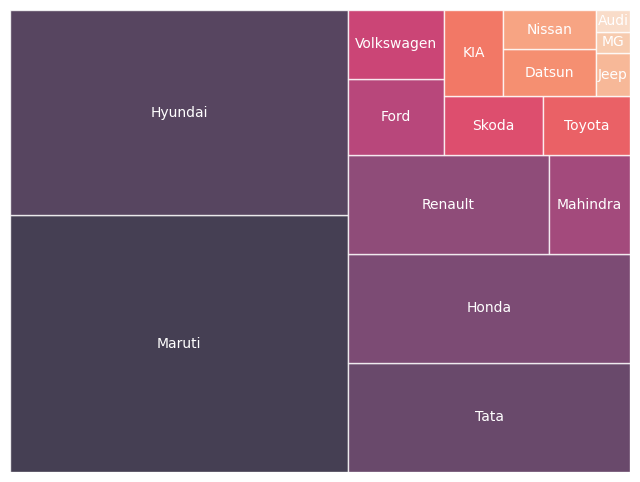

In [27]:
plt.figure(figsize=(8,6))
squarify.plot(sizes=brand_counts['Count'],
              label=brand_counts['brand'],
              alpha=0.8, color=sns.color_palette("rocket", len(brand_counts)), edgecolor='white', linewidth=1,
              text_kwargs={'color':'white', 'fontsize':10})
plt.axis('off')
plt.savefig('brand_count.png', dpi=300, bbox_inches='tight')
plt.show()


<ipython-input-28-dae93ef5ec7f>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha='right')


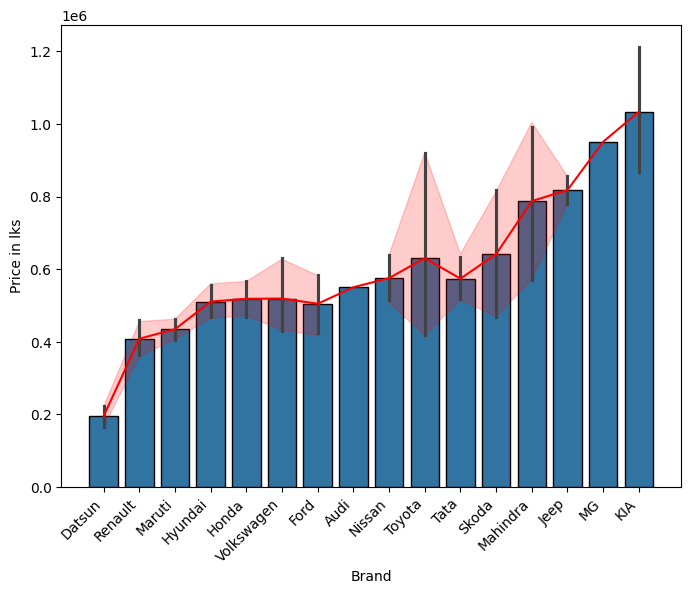

In [28]:
plt.figure(figsize = (8,6))
sorted_brands = A_data.groupby('brand')['price'].median().sort_values().index
plot = sns.barplot(data = A_data,x = 'brand',y = 'price',order=sorted_brands,edgecolor = 'Black',linewidth =1)
sns.lineplot(data = A_data,x = 'brand',y = 'price',color = 'r')
plot.set_xlabel('Brand')
plot.set_ylabel('Price in lks')
plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha='right')
plt.savefig('price_brand.png', dpi=300, bbox_inches='tight')

###  2. What is the relationship between kilometers driven and price?

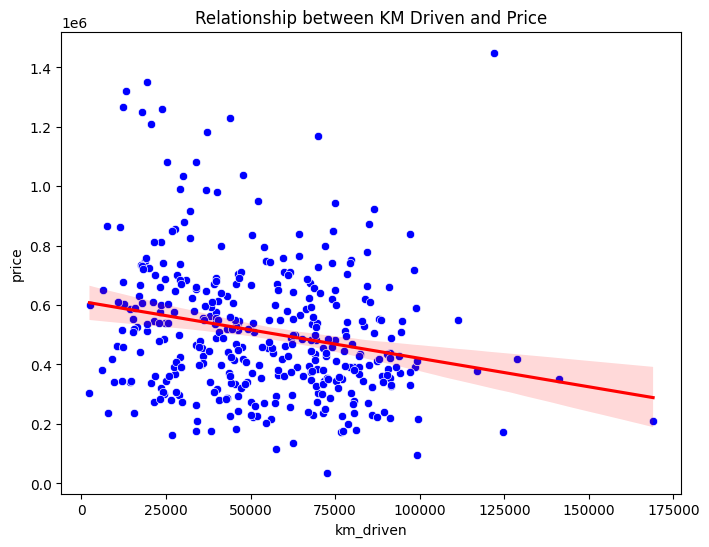

In [29]:
plt.figure(figsize = (8,6))
plot = sns.scatterplot(data = A_data,x = 'km_driven',y = 'price',color = 'b')
sns.regplot(data = A_data,x = 'km_driven',y = 'price',scatter=False,color = 'red')
plt.title('Relationship between KM Driven and Price')
plt.savefig('Relationship between KM Driven and Price.png', dpi=300, bbox_inches='tight')

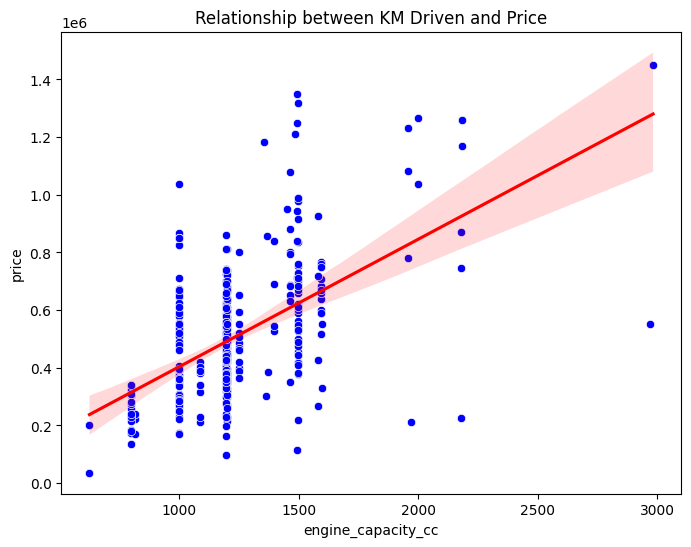

In [30]:
plt.figure(figsize = (8,6))
plot = sns.scatterplot(data = A_data,x = 'engine_capacity_cc',y = 'price',color = 'b')
sns.regplot(data = A_data,x = 'engine_capacity_cc',y = 'price',scatter=False,color = 'red')
plt.title('Relationship between KM Driven and Price')
plt.savefig('Relationship between engine capacity and Price.png', dpi=300, bbox_inches='tight')

### 3. How does fuel type affect resale price and demand?

<ipython-input-31-6815f2b45aca>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = A_data,x = 'fuel',y = 'price',palette='husl',edgecolor = 'Black',linewidth =1)


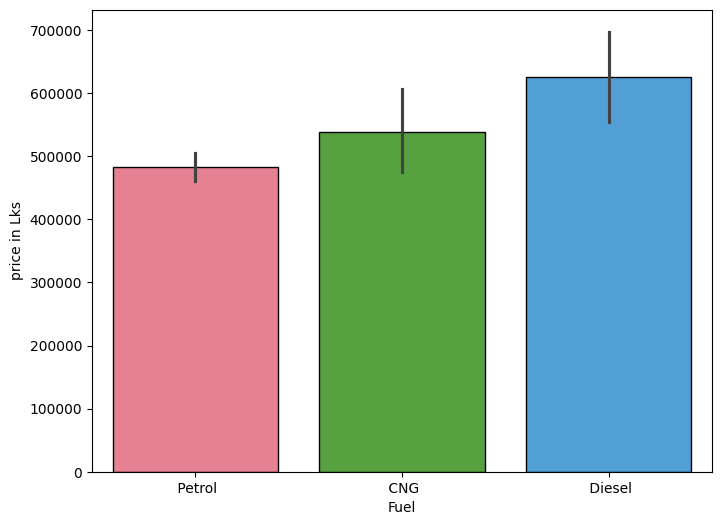

In [31]:
plt.figure(figsize=(8,6))
sns.barplot(data = A_data,x = 'fuel',y = 'price',palette='husl',edgecolor = 'Black',linewidth =1)
plt.xlabel("Fuel")
plt.ylabel("price in Lks")
plt.savefig('Relationship between fuel and Price.png', dpi=300, bbox_inches='tight')

<ipython-input-32-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-32-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-32-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


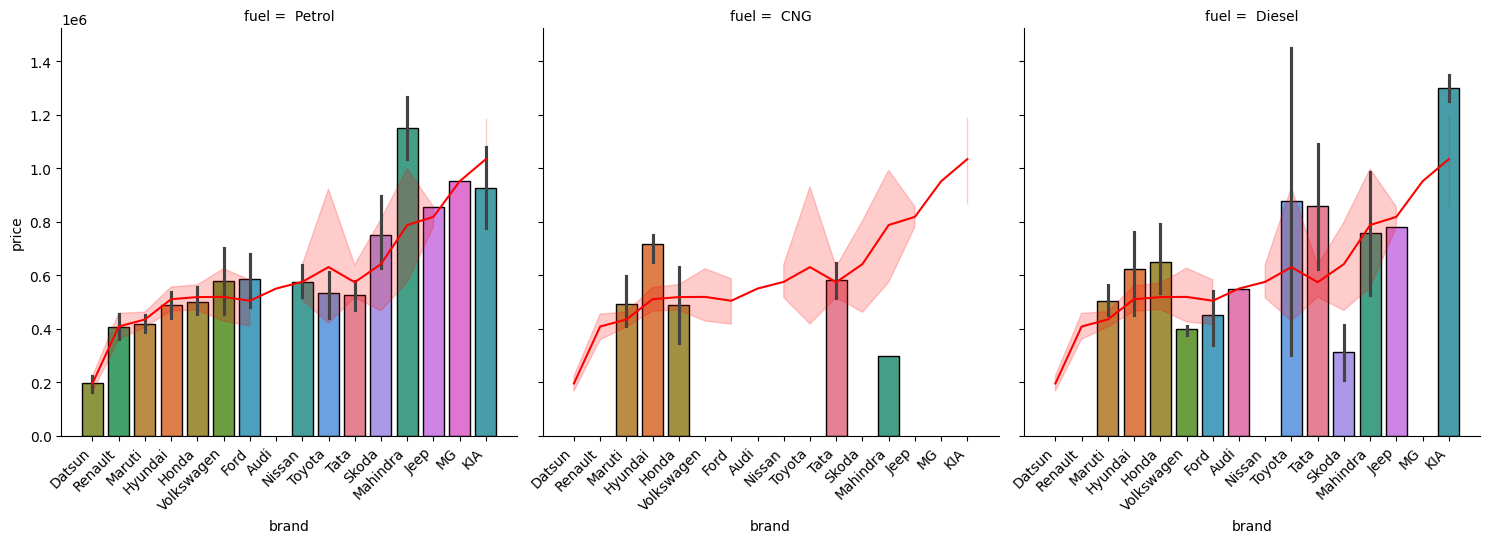

In [32]:
sorted_brands = A_data.groupby('brand')['price'].median().sort_values().index
g = sns.catplot(data=A_data, x = 'brand', y='price', col='fuel', kind='bar',hue ='brand',order=sorted_brands,edgecolor = 'Black',linewidth =1)
for ax in g.axes.flat:
    sns.lineplot(data = A_data,x = 'brand',y = 'price',color = 'r', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.savefig('Relationship between fuel and Price 2.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Do automatic cars have higher resale value than manual ones?

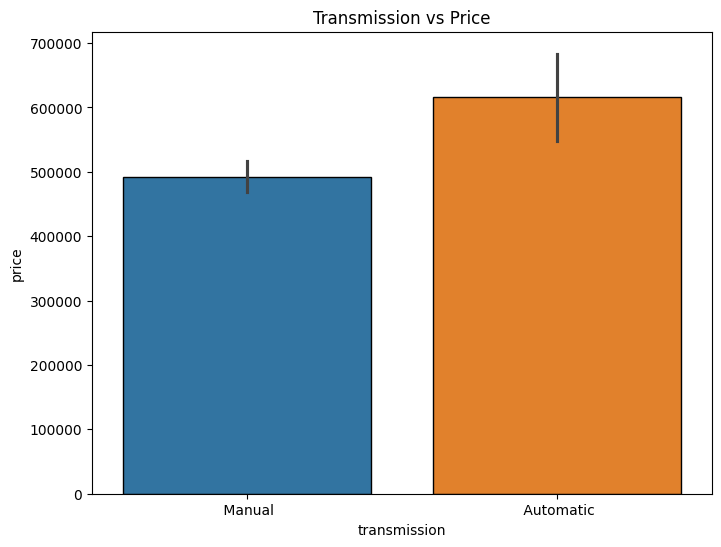

In [33]:
plt.figure(figsize = (8,6))
sns.barplot(data = A_data,x = 'transmission',y = 'price', hue = 'transmission',edgecolor = 'Black',linewidth =1)
plt.title('Transmission vs Price')
plt.savefig('transmission and Price.png', dpi=300, bbox_inches='tight')

###  5. How does ownership history (1st, 2nd, etc.) affect the price?

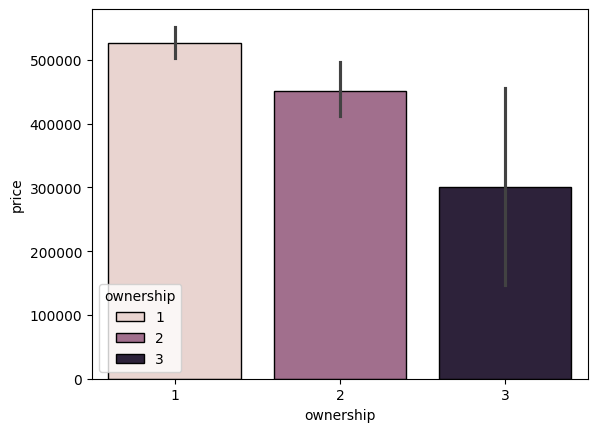

In [34]:
sns.barplot(data = A_data,x = 'ownership',y = 'price',hue = 'ownership',edgecolor = 'black',linewidth = 1)
plt.savefig('ownership vs price.jpg',dpi = 400)

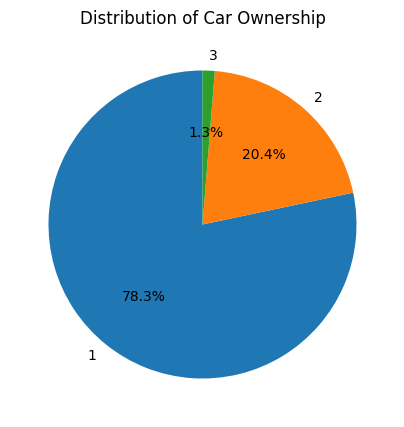

In [35]:
ownership_counts = A_data['ownership'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(ownership_counts, labels=ownership_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Car Ownership')
plt.savefig('Distribution of Car Ownership',dpi = 400)
plt.show()

### 6. How does the presence of insurance affect resale value?

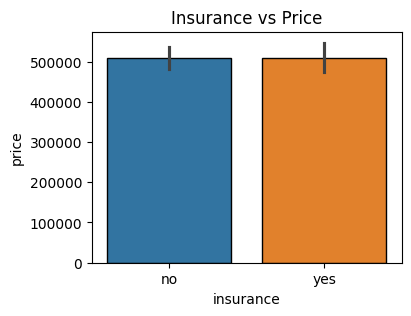

In [36]:
plt.figure(figsize=(4,3))
sns.barplot(data= A_data,x = 'insurance', y = 'price',hue = 'insurance',edgecolor = 'Black',linewidth =1)
plt.title('Insurance vs Price')
plt.savefig('Insurance vs Price.jpg',dpi = 300,bbox_inches = 'tight')

### Correlation plot between numaric data

In [37]:
A_data.insurance =[1 if i == 'yes' else 0 for i in A_data.insurance]

In [38]:
A_data.insurance.value_counts()

,count
insurance,
0,231
1,161


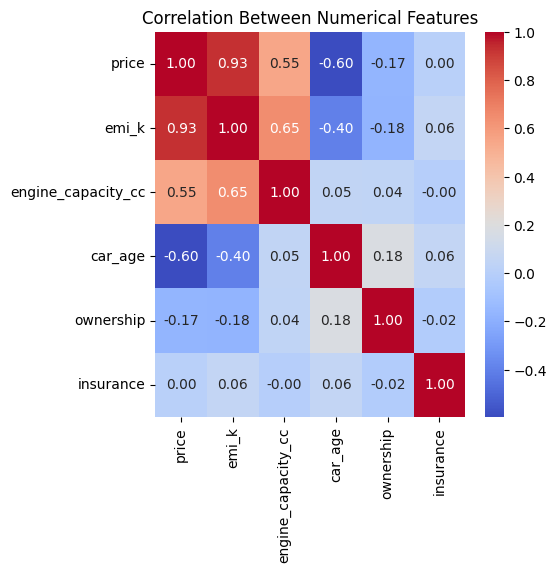

In [39]:
plt.figure(figsize=(5,5))
corrl=A_data[['price', 'emi_k', 'engine_capacity_cc','car_age','ownership','insurance']].corr()
sns.heatmap(corrl,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Between Numerical Features")
plt.savefig("corrl.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
avg_price_age=A_data.groupby('car_age')['price'].mean().reset_index()

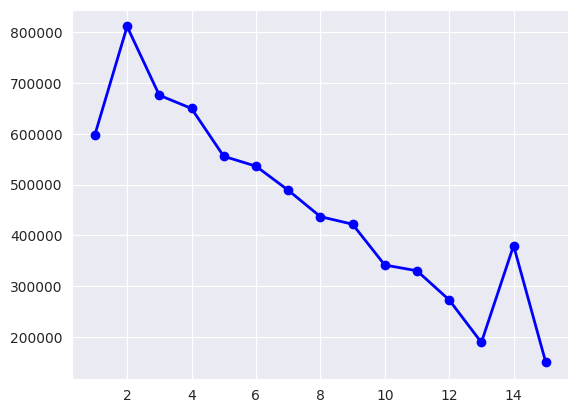

In [41]:
sns.set_style("darkgrid")
plt.plot( 'car_age', 'price', data=avg_price_age, marker='o', color='blue',linewidth =2)
plt.savefig('car_age vs price.jpg',dpi = 400)
plt.show()